# Cervical cancer cell classification using transfer learning

This notebook presents a complete experimental pipeline for multi-class classification of cells from the Cervical Cancer (SIPaKMeD) dataset using convolutional neural networks and transfer learning. This classification is significant because it involves the analysis of cells from the Pap smear test, with the goal of automatically identifying normal, abnormal, and suspicious changes in cervical cells.

## 1. Preparing environment

In this part, we are preparing our environment.

In [1]:
import os
from collections import Counter
import pandas as pd
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB0, EfficientNetB4, ResNet50
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
import seaborn as sns
from sklearn.metrics import confusion_matrix

2026-04-08 22:00:46.962860: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775685647.361087      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775685647.475082      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775685648.471118      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775685648.471167      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775685648.471170      24 computation_placer.cc:177] computation placer alr

## 2. Downloading dataset

The SIPaKMeD / Cervical Cancer dataset is loaded from the Kaggle platform. The goal is to ensure automatic and consistent data loading without manual file copying.

In [2]:
path = "/kaggle/input/datasets/prahladmehandiratta/cervical-cancer-largest-dataset-sipakmed"

## 3. Building the image list and corresponding classes

In this step, we iterate through the class folders and extract image paths from the "CROPPED" directory.

Why are CROPPED images used?

Since the cells have already been isolated from the wider microscopic scene, the model focuses on the morphological characteristics of the cell itself rather than the background. This is especially important for medical images, as it reduces noise and enables more stable learning.
Classes in the experiment:

* im_Dyskeratotic
* im_Koilocytotic
* im_Metaplastic
* im_Parabasal
* im_Superficial-Intermediate

Since I don't have any medical background, I researched the differences between these classes. 
**(I might be wrong!)**
These classes do not carry the same "weight" in a medical sense. According to the SIPaKMeD literature:

* Superficial-Intermediate and Parabasal are considered normal cells
* Koilocytotic and Dyskeratotic are considered abnormal cells
* Metaplastic is a benign but suspicious (potentially pre-cancerous) change, which makes it particularly interesting for classification.

In [3]:
cropped_bmp_files = []

class_folders = [
    "im_Dyskeratotic",
    "im_Koilocytotic",
    "im_Metaplastic",
    "im_Parabasal",
    "im_Superficial-Intermediate"
]

# Folder structure: root/im_Parabasal/im_Parabasal
# Each folder contains both original (full-size) images and cropped images.
# Cropped images contain a single cell, while original images contain the entire sample.
for class_name in class_folders:
    cropped_dir = os.path.join(path, class_name, class_name, "CROPPED")

    # The folder contains not only images but also .dat files, which cannot be loaded.
    # Therefore, we select only files with the .bmp extension.
    for file_name in os.listdir(cropped_dir):
        if file_name.lower().endswith(".bmp"):
            file_path = os.path.join(cropped_dir, file_name)
            cropped_bmp_files.append((class_name, file_path))

class_counts = Counter(label for label, _ in cropped_bmp_files)

print(f"Total cropped BMP images:{len(cropped_bmp_files)}")
print(class_counts)

Total cropped BMP images:4049
Counter({'im_Superficial-Intermediate': 831, 'im_Koilocytotic': 825, 'im_Dyskeratotic': 813, 'im_Metaplastic': 793, 'im_Parabasal': 787})


## 4. Creating a DataFrame

Here, the list of image paths and labels is converted into a DataFrame. This ensures a clear organization of the data and simplifies the subsequent splitting into training, validation, and test sets.

In [4]:
df = pd.DataFrame(cropped_bmp_files, columns=["label", "filepath"])

print(df.head())
print()
print("Total rows:", len(df))
print()
print(df["label"].value_counts())

             label                                           filepath
0  im_Dyskeratotic  /kaggle/input/datasets/prahladmehandiratta/cer...
1  im_Dyskeratotic  /kaggle/input/datasets/prahladmehandiratta/cer...
2  im_Dyskeratotic  /kaggle/input/datasets/prahladmehandiratta/cer...
3  im_Dyskeratotic  /kaggle/input/datasets/prahladmehandiratta/cer...
4  im_Dyskeratotic  /kaggle/input/datasets/prahladmehandiratta/cer...

Total rows: 4049

label
im_Superficial-Intermediate    831
im_Koilocytotic                825
im_Dyskeratotic                813
im_Metaplastic                 793
im_Parabasal                   787
Name: count, dtype: int64


## 5. Splitting the data into train, validation and test sets

The data is split into three parts:
  * **train** - the set used for model training ~ 80%
  * **validation** - the set used for monitoring generalization during training ~ 10%
  * **test** - the set used for final performance evaluation ~ 10%

Stratified splitting (stratify) is used to ensure that the class distribution remains approximately the same across all sets. This is an important practice in medical image classification, as it reduces the risk of any class being underrepresented in one of the subsets.

In [5]:
train_df, test_df = train_test_split(df, test_size=0.1, stratify=df["label"], random_state=42)

In [6]:
train_df, val_df = train_test_split(train_df, test_size=0.1111, stratify=train_df["label"], random_state=42)

### 5.1. Verifying the distribution across sets

After splitting, it is necessary to verify:
  * The total number of samples per set
  * The class distribution within each set

This step is performed to confirm that the stratified split successfully preserved the representativeness of all classes in each subset.

In [7]:
print(f"Training set: {len(train_df)}")
print(f"Validation set: {len(val_df)}")
print(f"Test set: {len(test_df)}")

print(f"\nTraining distribution:\n{train_df['label'].value_counts()}")
print(f"\nValidation distribution:\n{val_df['label'].value_counts()}")
print(f"\nTest distribution:\n{test_df['label'].value_counts()}")

Training set: 3239
Validation set: 405
Test set: 405

Training distribution:
label
im_Superficial-Intermediate    665
im_Koilocytotic                659
im_Dyskeratotic                651
im_Metaplastic                 635
im_Parabasal                   629
Name: count, dtype: int64

Validation distribution:
label
im_Koilocytotic                83
im_Superficial-Intermediate    83
im_Dyskeratotic                81
im_Parabasal                   79
im_Metaplastic                 79
Name: count, dtype: int64

Test distribution:
label
im_Koilocytotic                83
im_Superficial-Intermediate    83
im_Dyskeratotic                81
im_Metaplastic                 79
im_Parabasal                   79
Name: count, dtype: int64


## 6. Defining image dimensions, batch size, and augmentation


### Image dimensions:
The input image size is set to 224x224, which corresponds to the standard input size for `EfficientNetB0, EfficientNetB4 and ResNet50`.

### Batch size
`BATCH_SIZE = 32` represents a good compromise between training speed and memory consumption.

### Augmentation
The following transformations are applied to the training set:
  * rotation
  * horizontal and vertical shifts
  * zoom
  * horizontal flip

The goal of augmentation is to expose the model to more variations of the same classes and reduce overfitting.

The validation and test sets do not undergo augmentation, as they should represent real, unmodified data.



In [8]:
IMG_SIZE = (224, 224) # For EfficientNetB0, EfficientNetB4, ResNet50
BATCH_SIZE = 32 # Standard choice

# Augmentation
train_datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.05,
    height_shift_range=0.05,
    zoom_range=0.1,
    horizontal_flip=True
)

val_test_datagen = ImageDataGenerator() # No augmentation for validation and test data

## 7. Creating image data generators

`flow_from_dataframe` allows images to be loaded directly from the paths specified in the `DataFrame`.

### Advantages of generators
  * Does not load the entire dataset into memory at once
  * Enables batch processing
  * Can combine augmentation and labeling
  * Practical for working with larger image datasets

`shuffle=True` is used for the training generator, while validation and test generators use a stable order for easier evaluation.


In [9]:
train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col="filepath",
    y_col="label",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True
)

val_generator = val_test_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col="filepath",
    y_col="label",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

test_generator = val_test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col="filepath",
    y_col="label",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

Found 3239 validated image filenames belonging to 5 classes.
Found 405 validated image filenames belonging to 5 classes.
Found 405 validated image filenames belonging to 5 classes.


In [10]:
print(train_generator.class_indices)

{'im_Dyskeratotic': 0, 'im_Koilocytotic': 1, 'im_Metaplastic': 2, 'im_Parabasal': 3, 'im_Superficial-Intermediate': 4}


## 8. Defining model: Transfer Learning from ResNet50

This section uses the pretrained ResNet50 architecture with weights learned on the ImageNet dataset. In earlier iterations of this notebook, EfficientNetB0 and EfficientNetB4 were also tested, however ResNet50 empirically produced the best results on the test set.

Since it is very difficult to find a similar dataset (and medical datasets in general) that is large enough to train a deep network from scratch, a model that has already learned general visual patterns is used here and then fine tuned to the specific task.

By setting `base_model.trainable=False`, the previously learned weights are preserved, and only the final layers are trained for the new classification task. This reduces the risk of overfitting and speeds up training.

Later in this notebook, we will attempt to fine-tune the model by unfreezing the top layers of the base model. However, this will prove to be counterproductive; both unfreezing the last 20 layers and the last 75 layers were tested, and neither gave a meaningful improvement. In fact, the model's accuracy was lower after fine-tuning compared to the frozen baseline. This suggests that the pretrained ResNet50 features generalize well enough to this domain, and that the added flexibility of fine tuning introduces more noise than signal given the size of the dataset.

In [11]:
num_classes = len(train_generator.class_indices)

#base_model = EfficientNetB0( # Transfer Learning
#    weights="imagenet",
#    include_top=False,
#    input_shape=(224, 224, 3)
#)

base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

#base_model = EfficientNetB4(
#    weights="imagenet",
#    include_top=False,
#    input_shape=(224, 224, 3)
#)

# Model freeze
base_model.trainable = False

inputs = layers.Input(shape=(224, 224, 3))

x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)

x = layers.BatchNormalization()(x)
x = layers.Dense(512, activation="relu")(x)
x = layers.Dropout(0.3)(x)

x = layers.BatchNormalization()(x)
x = layers.Dense(256, activation="relu")(x)
x = layers.Dropout(0.2)(x)

outputs = layers.Dense(num_classes, activation="softmax")(x)

model = models.Model(inputs, outputs)

model.summary()

I0000 00:00:1775685699.158759      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1775685699.165320      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 2048)           │         8,192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,779,653 (94.53 MB)

 Trainable params: 1,186,821 (4.53 MB)

 Non-trainable params: 23,592,832 (90.00 MB)

## 9. Model compile

The model is compiled using:
  * AdamW optimizer,
  * categorical crossentropy loss with label smoothing
  * accuracy metric

In [12]:
optimizer = tf.keras.optimizers.AdamW(learning_rate=1e-4)

loss_fn = tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1)

model.compile(
    optimizer=optimizer,
    loss=loss_fn,
    metrics=["accuracy"]
)

## 10. Callback mechanisms during training

Three important callbacks are used during training:
  * **Early stopping** - stops training when validation performance ceases to improve
  * **ModelCheckpoint** - saves the best version of the model
  * **ReduceLROnPlateau** - reduces the learning rate when progress slows down

In [13]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

checkpoint = ModelCheckpoint(
    #"best_efficientnet_cervical.keras",
    #"best_efficientNetB4_cervical.keras",
    "best_resnet50_cervical.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

## 11. Model training

In this step, the model iterates through epochs and learns from the training set, while its performance on the validation set is evaluated after each epoch.

In [14]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=50,
    callbacks=[early_stop, checkpoint, reduce_lr]
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50


I0000 00:00:1775685714.846863      73 service.cc:152] XLA service 0x7a0244050d30 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775685714.846909      73 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1775685714.846913      73 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1775685717.535994      73 cuda_dnn.cc:529] Loaded cuDNN version 91002


  1/102 ━━━━━━━━━━━━━━━━━━━━ 33:33 20s/step - accuracy: 0.1250 - loss: 2.0490

I0000 00:00:1775685725.069466      73 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 688ms/step - accuracy: 0.5363 - loss: 1.3530
Epoch 1: val_loss improved from inf to 0.78398, saving model to best_resnet50_cervical.keras
102/102 ━━━━━━━━━━━━━━━━━━━━ 104s 834ms/step - accuracy: 0.5378 - loss: 1.3501 - val_accuracy: 0.8444 - val_loss: 0.7840 - learning_rate: 1.0000e-04
Epoch 2/50
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 432ms/step - accuracy: 0.8521 - loss: 0.7504
Epoch 2: val_loss improved from 0.78398 to 0.64436, saving model to best_resnet50_cervical.keras
102/102 ━━━━━━━━━━━━━━━━━━━━ 47s 455ms/step - accuracy: 0.8521 - loss: 0.7503 - val_accuracy: 0.8938 - val_loss: 0.6444 - learning_rate: 1.0000e-04
Epoch 3/50
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 430ms/step - accuracy: 0.8907 - loss: 0.6713
Epoch 3: val_loss improved from 0.64436 to 0.59412, saving model to best_resnet50_cervical.keras
102/102 ━━━━━━━━━━━━━━━━━━━━ 47s 457ms/step - accuracy: 0.8907 - loss: 0.6714 - val_accuracy: 0.9259 - val_loss: 0.5941 - learning_rate: 1.0000e-04
Epoch 4/50
102/

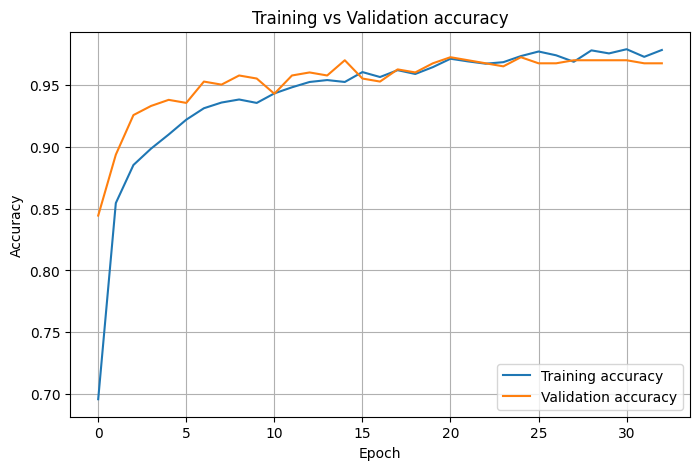

In [15]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label="Training accuracy")
plt.plot(history.history['val_accuracy'], label="Validation accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation accuracy")

plt.legend()
plt.grid()

plt.show()

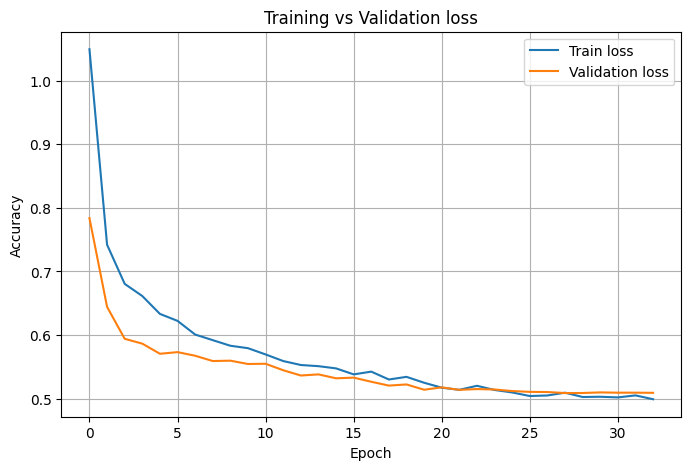

In [16]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label="Train loss")
plt.plot(history.history['val_loss'], label="Validation loss")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation loss")

plt.legend()
plt.grid()

plt.show()

## 12. Evaluation on the test set

After training is complete, the model is evaluated on the test set, which was not used for either training or parameter selection.

In [17]:
test_loss, test_accuracy = model.evaluate(test_generator)
print(f"Test loss: {test_loss}" )
print(f"Test accuracy: {test_accuracy}")

13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 408ms/step - accuracy: 0.9643 - loss: 0.4988
Test loss: 0.4910734295845032
Test accuracy: 0.970370352268219


## 13. Fine tuning

After evaluation on the test set, this section focuses on the fine tuning process by unfreezing the top layers of the base model. The goal of this procedure is to adapt the pre-trained weights to our dataset in order to achieve higher classification accuracy.

In [18]:
# Fine tunning
base_model.trainable = True

for layer in base_model.layers[:-20]:
    layer.trainable = False


optimizer = tf.keras.optimizers.AdamW(learning_rate=1e-5, weight_decay=1e-4)

model.compile(
    optimizer=optimizer,
    loss=loss_fn,
    metrics=["accuracy"]
)

checkpoint_finetune = ModelCheckpoint(
    "best_resnet50_finetuned_cervical.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

history_finetune = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=50,
    callbacks=[early_stop, checkpoint_finetune, reduce_lr]
)

Epoch 1/50
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 504ms/step - accuracy: 0.9441 - loss: 0.5680
Epoch 1: val_loss improved from inf to 0.53335, saving model to best_resnet50_finetuned_cervical.keras
102/102 ━━━━━━━━━━━━━━━━━━━━ 84s 605ms/step - accuracy: 0.9440 - loss: 0.5679 - val_accuracy: 0.9580 - val_loss: 0.5333 - learning_rate: 1.0000e-05
Epoch 2/50
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 425ms/step - accuracy: 0.9530 - loss: 0.5430
Epoch 2: val_loss did not improve from 0.53335
102/102 ━━━━━━━━━━━━━━━━━━━━ 45s 438ms/step - accuracy: 0.9530 - loss: 0.5430 - val_accuracy: 0.9580 - val_loss: 0.5338 - learning_rate: 1.0000e-05
Epoch 3/50
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 424ms/step - accuracy: 0.9497 - loss: 0.5467
Epoch 3: val_loss improved from 0.53335 to 0.53070, saving model to best_resnet50_finetuned_cervical.keras
102/102 ━━━━━━━━━━━━━━━━━━━━ 46s 451ms/step - accuracy: 0.9497 - loss: 0.5466 - val_accuracy: 0.9630 - val_loss: 0.5307 - learning_rate: 1.0000e-05
Epoch 4/50
102/102 ━━━━━━━━━━━━━━━━

## 13. Evaluation on the test set after fine tuning

After the fine tuning training is complete, the model is evaluated again on the test set, which was not used for either training or parameter selection.

In [19]:
test_loss, test_accuracy = model.evaluate(test_generator)
print(f"Test loss after fine tunning: {test_loss}")
print(f"Test accuracy after fine tunning: {test_accuracy}")

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 100ms/step - accuracy: 0.9572 - loss: 0.5067
Test loss after fine tunning: 0.5013293027877808
Test accuracy after fine tunning: 0.9629629850387573


## 14. Confusion matrix

After the fine tuning training is complete, the model is evaluated once again on the test set, which was not used for either training or parameter selection.

In [20]:
y_pred_probs = model.predict(test_generator)
y_pred = np.argmax(y_pred_probs, axis=1)

y_true = test_generator.classes
cm = confusion_matrix(y_true, y_pred)

class_names = list(test_generator.class_indices.keys())


13/13 ━━━━━━━━━━━━━━━━━━━━ 9s 417ms/step


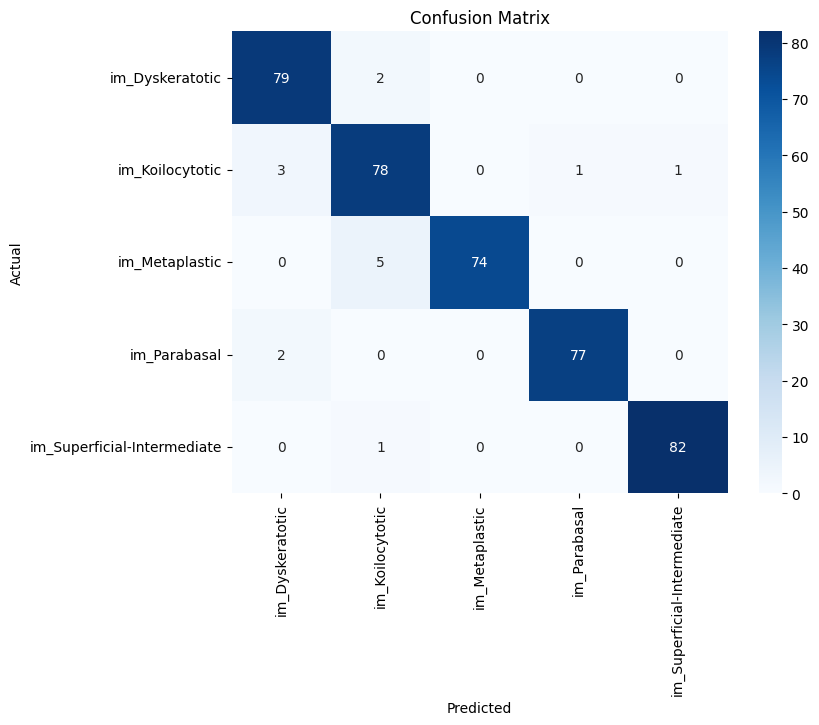

In [21]:
plt.figure(figsize=(8,6))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",xticklabels=class_names, yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [22]:
from IPython.display import FileLink
FileLink("best_resnet50_cervical.keras")

/kaggle/working/best_resnet50_cervical.keras

In [23]:
FileLink("best_resnet50_finetuned_cervical.keras")

/kaggle/working/best_resnet50_finetuned_cervical.keras